# utils

In [1]:

import os 
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
def extract_sp500_companies(url = "https://es.wikipedia.org/wiki/Anexo:Compa%C3%B1%C3%ADas_del_S%26P_500" , export = True) : 
    # Leer todas las tablas de la página
    tables = pd.read_html(url)
    df = tables[0]
    if export : 
        df.to_csv("data/sp500_companies.csv")
    return df


# Importing data

In [3]:
df = extract_sp500_companies()
companies = df['Símbolo']
df.head(5)

,Símbolo,Seguridad,Presentación ante la SEC,Sector GICS,Sub-industria GICS,Ubicación de la sede,Fecha de incorporación,Clave de índice central,Fundada
0,MMM,3M,reports,Industriales,Conglomerados Industriales,"Saint Paul, Minnesota",1976-08-09,66740.0,1902
1,AOS,A. O. Smith,reports,Industriales,Productos de Edificio,"Milwaukee, Wisconsin",2017-07-26,91142.0,1916
2,ABT,Abbott,reports,Cuidado de Salud,Health Care Equipment,"North Chicago, Illinois",1964-03-31,1800.0,1888
3,ABBV,AbbVie,reports,Cuidado de Salud,Farmacéuticos,"North Chicago, Illinois",2012-12-31,1551152.0,2013 (1888)
4,ACN,Accenture,reports,Tecnología Informática,Consultoría Informática y Otros Servicios,"Dublin, Ireland",2011-07-06,1467373.0,1989


In [4]:
import numpy as np
print("NumPy path:", np.__file__)
print("NumPy version:", np.__version__)
print("¿`matrix` existe?", "matrix" in dir(np))

NumPy path: d:\Proyectos\SP500-OPT\tfg\.venv\Lib\site-packages\numpy\__init__.py
NumPy version: 2.3.1
¿`matrix` existe? True


In [5]:

from tiingo import TiingoClient

# 2) Configura tu API key de Tiingo
config = {
    'api_key': '47e54830ca20ce085f4734cef238006b979196f3'
}
client = TiingoClient(config)
tickers =companies.tolist()
tickers =tickers[:5]
all_data = []  # para acumular cada DataFrame individual

for symbol in tickers:

        prices = client.get_ticker_price(
            symbol,
            fmt='json',                    # formato JSON para convertir directamente a DataFrame
            startDate='1900-01-01',        # muy antiguo para asegurarnos de pillar desde el IPO
            endDate='2025-01-31',          # hoy (por defecto)
            frequency='daily'              # también podrías usar 'weekly'
        )
        df = pd.DataFrame(prices)
        df=df[['date','adjClose','adjHigh','adjOpen','adjLow','adjVolume','divCash','splitFactor']]
        df['date'] = pd.to_datetime(df['date'], format="ISO8601")
        df.to_csv(f"data/tiingo/{symbol}.csv") 

folder=r'data/tiingo'
all_data = []
date_column = None  # Para guardar la columna 'Date' una vez

for stock_data in os.listdir(folder):
    file_path = os.path.join(folder, stock_data)
    df = pd.read_csv(file_path)
    
    symbol = os.path.splitext(stock_data)[0]
    symbol=symbol.replace('raw_','')
        # Extraer la columna Date una sola vez
    cols=['adjClose','adjHigh','adjOpen','adjLow','adjVolume','divCash','splitFactor']
    df = df[['date']+cols]
    df = df.set_index('date')  # Usar 'Date' como índice para alineación
    df[['adjClose','adjHigh','adjOpen','adjLow','adjVolume']].columns=['Close','High','Open','Low','Volume']
    df.columns=[f'{col}_{symbol}' for col in cols]
    all_data.append(df)
    final_dataset = pd.concat(all_data,axis=1 ,join='outer')
    final_dataset.sort_index(inplace=True)
    final_dataset.to_csv(r'data/final_tiingo.csv', index=True)
    
display(final_dataset)




,adjClose_ABBV,adjHigh_ABBV,adjOpen_ABBV,adjLow_ABBV,adjVolume_ABBV,divCash_ABBV,splitFactor_ABBV,adjClose_ABT,adjHigh_ABT,adjOpen_ABT,...,adjVolume_AOS,divCash_AOS,splitFactor_AOS,adjClose_MMM,adjHigh_MMM,adjOpen_MMM,adjLow_MMM,adjVolume_MMM,divCash_MMM,splitFactor_MMM
date,,,,,,,,,,,,,,,,,,,,,
1970-01-02 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.872528,1.883289,1.872528,1.870478,85315,0.0,1.0
1970-01-05 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.883289,1.885510,1.874748,1.874748,528954,0.0,1.0
1970-01-06 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.902592,1.902592,1.883289,1.881069,208548,0.0,1.0
1970-01-07 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.913183,1.917453,1.902592,1.898151,195277,0.0,1.0
1970-01-08 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.938806,1.943076,1.913183,1.908912,360219,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-27 00:00:00+00:00,173.745410,174.285602,169.581021,169.512269,6985212.0,0.0,1.0,128.252338,128.579335,125.576904,...,1112217.0,0.00,1.0,150.037439,150.512742,147.542096,147.452977,4929615,0.0,1.0
2025-01-28 00:00:00+00:00,171.692681,174.000774,173.647194,170.631940,5604051.0,0.0,1.0,126.230899,128.668516,128.569426,...,1397019.0,0.00,1.0,149.918613,151.463349,149.839396,148.324465,4286762,0.0,1.0
2025-01-29 00:00:00+00:00,172.134656,173.765054,171.388209,171.191775,3748422.0,0.0,1.0,126.696623,128.123520,126.993893,...,1513081.0,0.00,1.0,150.057243,151.285110,150.017635,149.166049,3996082,0.0,1.0


Text(0.5, 0, 'Market Days')

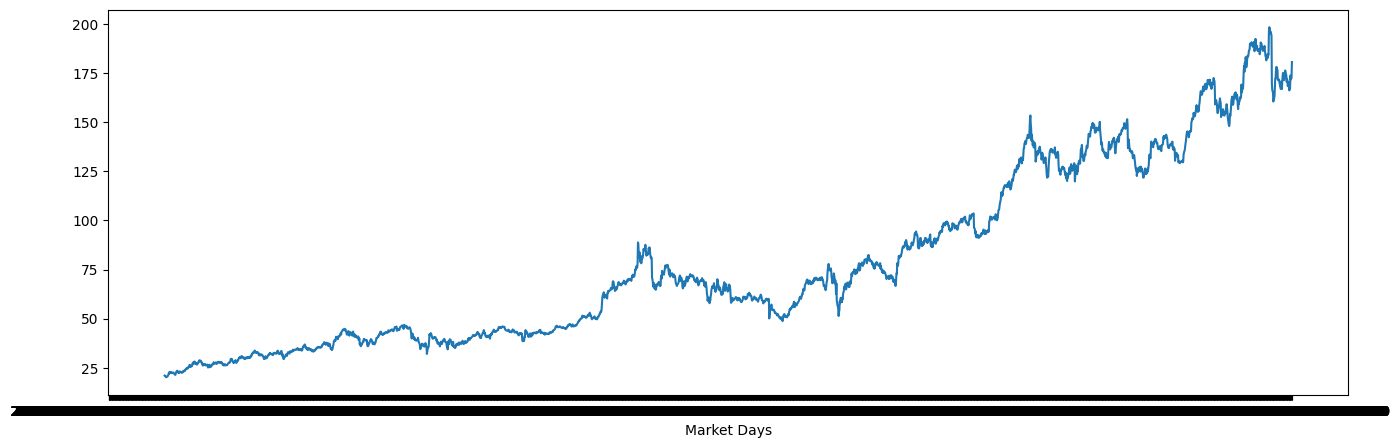

In [ ]:

go 
